In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load the train and test data
train_df = pd.read_csv('train.csv', sep=',')
test_df = pd.read_csv('test.csv', sep=',')

# Merge the train and test data (nur für Clustering-Analyse)
df = pd.concat([train_df, test_df], ignore_index=True)

# Display the first few rows of the merged dataframe
print("Titanic Dataset:")
display(df.head())
print("\nDataset Info:")
df.info()
print(f"\nTotal rows: {len(df)}")
print(f"Features: {df.columns.tolist()}")

Titanic Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB

Total rows: 1309
Features: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [22]:
# Data Preprocessing für Clustering
df_cluster = df.copy()

# Feature Engineering
# 1. Fehlende Werte behandeln
df_cluster['Age'].fillna(df_cluster['Age'].median(), inplace=True)
df_cluster['Fare'].fillna(df_cluster['Fare'].median(), inplace=True)
df_cluster['Embarked'].fillna(df_cluster['Embarked'].mode()[0], inplace=True)

# 2. Kategorische Variablen in numerisch umwandeln
df_cluster['Sex_numeric'] = df_cluster['Sex'].map({'male': 0, 'female': 1})
df_cluster['Embarked_numeric'] = df_cluster['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# 3. Features für Clustering auswählen
feature_cols = ['Pclass', 'Sex_numeric', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_numeric']
X = df_cluster[feature_cols].copy()

# 4. Fehlende Werte in X prüfen und behandeln
X = X.fillna(X.median())

print("Features für Clustering:")
print(X.head())
print(f"\nShape: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Zielvariable (nur für Evaluation)
y = df_cluster['Survived'].copy()
print(f"\nTarget variable 'Survived' - Missing: {y.isnull().sum()}")

Features für Clustering:
   Pclass  Sex_numeric   Age  SibSp  Parch     Fare  Embarked_numeric
0       3            0  22.0      1      0   7.2500                 2
1       1            1  38.0      1      0  71.2833                 0
2       3            1  26.0      0      0   7.9250                 2
3       1            1  35.0      1      0  53.1000                 2
4       3            0  35.0      0      0   8.0500                 2

Shape: (1309, 7)
Missing values: 0

Target variable 'Survived' - Missing: 418


C:\Users\kathy\AppData\Local\Temp\ipykernel_16488\2877998879.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cluster['Age'].fillna(df_cluster['Age'].median(), inplace=True)
C:\Users\kathy\AppData\Local\Temp\ipykernel_16488\2877998879.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [23]:
# Feature Normalisierung (wichtig für K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features wurden standardisiert (StandardScaler)")
print(f"Shape: {X_scaled.shape}")
print(f"\nFeature Statistiken nach Skalierung:")
print(f"Mean: {X_scaled.mean(axis=0).round(2)}")
print(f"Std: {X_scaled.std(axis=0).round(2)}")

Features wurden standardisiert (StandardScaler)
Shape: (1309, 7)

Feature Statistiken nach Skalierung:
Mean: [-0. -0.  0. -0.  0. -0.  0.]
Std: [1. 1. 1. 1. 1. 1. 1.]


In [24]:
# TRAIN/TEST SPLIT für valide Evaluation
# Nur Zeilen mit bekanntem 'Survived' verwenden
mask = ~y.isnull()
X_valid = X_scaled[mask]
y_valid = y[mask]

# Split in Train/Test (70% Training, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_valid, y_valid, test_size=0.3, random_state=42, stratify=y_valid
)

print("Train/Test Split erstellt:")
print(f"   Training samples: {len(X_train)} ({len(X_train)/len(X_valid)*100:.1f}%)")
print(f"   Test samples: {len(X_test)} ({len(X_test)/len(X_valid)*100:.1f}%)")
print(f"   Total samples: {len(X_valid)}")
print(f"\nSurvival Rate:")
print(f"   Training: {y_train.mean():.2%}")
print(f"   Test: {y_test.mean():.2%}")

Train/Test Split erstellt:
   Training samples: 623 (69.9%)
   Test samples: 268 (30.1%)
   Total samples: 891

Survival Rate:
   Training: 38.36%
   Test: 38.43%


In [25]:
# HILFSFUNKTION: Clustering & Evaluation mit Train/Test Split
def cluster_and_evaluate(k, X_train, X_test, y_train, y_test, random_state=42):
    """
    Führt K-Means Clustering durch und evaluiert mit echtem Train/Test Split
    - Training: Cluster werden auf Trainingsdaten gebildet
    - Testing: Testdaten werden vorhergesagt (keine Daten-Leakage!)
    
    Returns:
        dict: Metriken (train_accuracy, test_accuracy, f1_macro, silhouette_score, inertia)
    """
    if len(X_train) == 0 or len(X_test) == 0:
        return {
            "k": k, 
            "train_accuracy": 0, 
            "test_accuracy": 0, 
            "f1_macro": 0, 
            "silhouette": 0, 
            "inertia": 0
        }
    
    # K-Means Clustering NUR auf TRAINING-Daten
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    train_cluster_labels = kmeans.fit_predict(X_train)
    
    # Mapping: Cluster -> häufigster 'Survived' Wert (basierend auf TRAINING-Daten)
    cluster_to_survived = {}
    for cluster_id in range(k):
        cluster_mask = (train_cluster_labels == cluster_id)
        if cluster_mask.sum() > 0:
            survived_in_cluster = y_train.iloc[cluster_mask] if hasattr(y_train, 'iloc') else y_train[cluster_mask]
            most_common = survived_in_cluster.mode()[0] if len(survived_in_cluster.mode()) > 0 else 0
            cluster_to_survived[cluster_id] = most_common
    
    # Vorhersage auf TRAINING-Daten
    y_train_pred = np.array([cluster_to_survived.get(c, 0) for c in train_cluster_labels])
    train_acc = accuracy_score(y_train, y_train_pred)
    
    # Vorhersage auf TEST-Daten (das ist der wichtige Teil!)
    test_cluster_labels = kmeans.predict(X_test)
    y_test_pred = np.array([cluster_to_survived.get(c, 0) for c in test_cluster_labels])
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Weitere Metriken
    f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    silhouette = silhouette_score(X_train, train_cluster_labels) if k > 1 else 0
    inertia = kmeans.inertia_
    
    return {
        "k": k,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "f1_macro": f1,
        "silhouette": silhouette,
        "inertia": inertia
    }

print("Hilfsfunktion definiert: cluster_and_evaluate() mit Train/Test Split")

Hilfsfunktion definiert: cluster_and_evaluate() mit Train/Test Split


In [26]:
# EXPERIMENT: Verschiedene k-Werte testen mit Train/Test Split
k_values = [2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]

results = []
print("Starte Clustering-Experimente mit Train/Test Split...\n")

for k in k_values:
    result = cluster_and_evaluate(k, X_train, X_test, y_train, y_test)
    results.append(result)
    print(f"k={k:3d} | Train Acc={result['train_accuracy']:.4f} | Test Acc={result['test_accuracy']:.4f} | F1={result['f1_macro']:.4f} | Silhouette={result['silhouette']:.4f}")

results_df = pd.DataFrame(results)
print("\nAlle Experimente abgeschlossen!")
print("\nErgebnisse:")
display(results_df)

Starte Clustering-Experimente mit Train/Test Split...

k=  2 | Train Acc=0.6806 | Test Acc=0.6828 | F1=0.6455 | Silhouette=0.2786
k=  3 | Train Acc=0.6870 | Test Acc=0.6604 | F1=0.6477 | Silhouette=0.3079
k=  4 | Train Acc=0.7865 | Test Acc=0.7463 | F1=0.7399 | Silhouette=0.2876
k=  5 | Train Acc=0.7994 | Test Acc=0.7948 | F1=0.7802 | Silhouette=0.2971
k=  7 | Train Acc=0.7753 | Test Acc=0.7612 | F1=0.7403 | Silhouette=0.3265
k= 10 | Train Acc=0.7978 | Test Acc=0.8172 | F1=0.8085 | Silhouette=0.3395
k= 15 | Train Acc=0.8058 | Test Acc=0.8097 | F1=0.7993 | Silhouette=0.3544
k= 20 | Train Acc=0.8042 | Test Acc=0.8134 | F1=0.8014 | Silhouette=0.3704
k= 25 | Train Acc=0.8074 | Test Acc=0.8134 | F1=0.8021 | Silhouette=0.3740
k= 30 | Train Acc=0.8234 | Test Acc=0.8172 | F1=0.7967 | Silhouette=0.3750
k= 40 | Train Acc=0.8154 | Test Acc=0.8209 | F1=0.8024 | Silhouette=0.3995
k= 50 | Train Acc=0.8379 | Test Acc=0.8134 | F1=0.7942 | Silhouette=0.4138
k= 60 | Train Acc=0.8331 | Test Acc=0.8060 | 

,k,train_accuracy,test_accuracy,f1_macro,silhouette,inertia
0,2,0.680578,0.682836,0.645475,0.278573,3332.320934
1,3,0.686998,0.660448,0.647689,0.307931,2726.420681
2,4,0.786517,0.746269,0.739880,0.287642,2389.776294
3,5,0.799358,0.794776,0.780207,0.297056,2112.098823
4,7,0.775281,0.761194,0.740310,0.326527,1690.462127
5,10,0.797753,0.817164,0.808502,0.339532,1302.256928
6,15,0.805778,0.809701,0.799304,0.354447,990.782311
7,20,0.804173,0.813433,0.801387,0.370411,777.015982
8,25,0.807384,0.813433,0.802150,0.373956,656.086608
9,30,0.823435,0.817164,0.796715,0.375001,564.233141


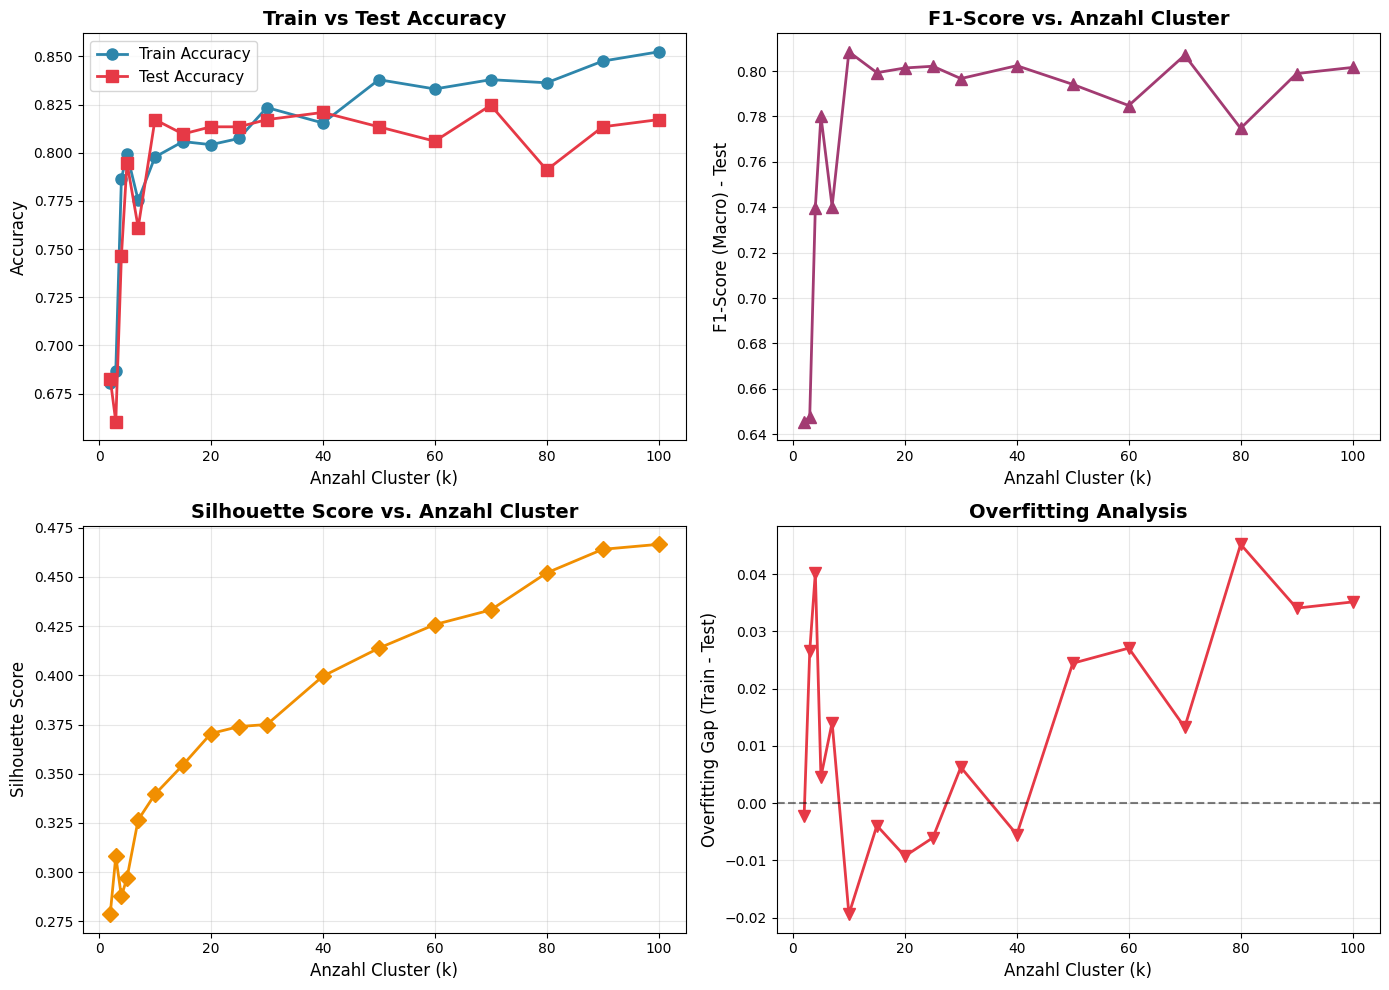


Beste Ergebnisse (basierend auf TEST-Performance):
   Best k (Test Accuracy): 70 mit Test Accuracy = 0.8246
   Best k (F1-Score): 10 mit F1 = 0.8085
   Best k (Silhouette): 100 mit Silhouette = 0.4666

Overfitting Analysis:
   Größte Diskrepanz (Train-Test): 0.0452 bei k=80


In [27]:
# VISUALISIERUNG: Train vs Test Accuracy & weitere Metriken
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Train vs Test Accuracy
axes[0, 0].plot(results_df['k'], results_df['train_accuracy'], marker='o', linewidth=2, markersize=8, color='#2E86AB', label='Train Accuracy')
axes[0, 0].plot(results_df['k'], results_df['test_accuracy'], marker='s', linewidth=2, markersize=8, color='#E63946', label='Test Accuracy')
axes[0, 0].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Train vs Test Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1-Score vs. k
axes[0, 1].plot(results_df['k'], results_df['f1_macro'], marker='^', linewidth=2, markersize=8, color='#A23B72')
axes[0, 1].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[0, 1].set_ylabel('F1-Score (Macro) - Test', fontsize=12)
axes[0, 1].set_title('F1-Score vs. Anzahl Cluster', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Silhouette Score vs. k
axes[1, 0].plot(results_df['k'], results_df['silhouette'], marker='D', linewidth=2, markersize=8, color='#F18F01')
axes[1, 0].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[1, 0].set_ylabel('Silhouette Score', fontsize=12)
axes[1, 0].set_title('Silhouette Score vs. Anzahl Cluster', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Overfitting Analysis (Train - Test Accuracy Gap)
accuracy_gap = results_df['train_accuracy'] - results_df['test_accuracy']
axes[1, 1].plot(results_df['k'], accuracy_gap, marker='v', linewidth=2, markersize=8, color='#E63946')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[1, 1].set_ylabel('Overfitting Gap (Train - Test)', fontsize=12)
axes[1, 1].set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Best k finden (basierend auf TEST-Accuracy!)
best_k_test_acc = results_df.loc[results_df['test_accuracy'].idxmax(), 'k']
best_k_f1 = results_df.loc[results_df['f1_macro'].idxmax(), 'k']
best_k_silhouette = results_df.loc[results_df['silhouette'].idxmax(), 'k']

print(f"\nBeste Ergebnisse (basierend auf TEST-Performance):")
print(f"   Best k (Test Accuracy): {int(best_k_test_acc)} mit Test Accuracy = {results_df['test_accuracy'].max():.4f}")
print(f"   Best k (F1-Score): {int(best_k_f1)} mit F1 = {results_df['f1_macro'].max():.4f}")
print(f"   Best k (Silhouette): {int(best_k_silhouette)} mit Silhouette = {results_df['silhouette'].max():.4f}")

# Overfitting Warning
max_gap = accuracy_gap.max()
max_gap_k = results_df.loc[accuracy_gap.idxmax(), 'k']
print(f"\nOverfitting Analysis:")
print(f"   Größte Diskrepanz (Train-Test): {max_gap:.4f} bei k={int(max_gap_k)}")
if max_gap > 0.1:
    print(f"   Warnung: Hoher Overfitting-Grad bei großen k-Werten!")

In [28]:
# DETAILLIERTE ANALYSE für das beste k (basierend auf Test Accuracy)
best_k = int(best_k_test_acc)
print(f"Detaillierte Analyse für k={best_k} (beste Test-Accuracy)\n")

# Clustering mit bestem k auf Trainingsdaten trainieren
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_cluster_labels = kmeans_best.fit_predict(X_train)

# Cluster-zu-Survived Mapping (basierend auf Trainingsdaten)
cluster_to_survived = {}
for cluster_id in range(best_k):
    cluster_mask = (train_cluster_labels == cluster_id)
    if cluster_mask.sum() > 0:
        survived_in_cluster = y_train.iloc[cluster_mask] if hasattr(y_train, 'iloc') else y_train[cluster_mask]
        most_common = survived_in_cluster.mode()[0] if len(survived_in_cluster.mode()) > 0 else 0
        cluster_to_survived[cluster_id] = most_common

# Vorhersagen auf Testdaten
test_cluster_labels = kmeans_best.predict(X_test)
y_test_pred = np.array([cluster_to_survived.get(c, 0) for c in test_cluster_labels])

# Classification Report für TESTDATEN
print("Classification Report (TEST SET):")
print(classification_report(y_test, y_test_pred, target_names=['Not Survived', 'Survived']))

# Cluster-Statistiken (Training)
print(f"\nCluster-Statistiken (Training Set, k={best_k}):")
for cluster_id in range(best_k):
    cluster_mask = (train_cluster_labels == cluster_id)
    n_samples = cluster_mask.sum()
    survived_in_cluster = y_train.iloc[cluster_mask] if hasattr(y_train, 'iloc') else y_train[cluster_mask]
    survival_rate = survived_in_cluster.mean() if n_samples > 0 else 0
    predicted_label = cluster_to_survived.get(cluster_id, 0)
    
    print(f"  Cluster {cluster_id}: {n_samples} Samples | Survival Rate: {survival_rate:.2%} | Predicted: {'Survived' if predicted_label == 1 else 'Not Survived'}")

# Test Set Cluster-Verteilung
print(f"\nCluster-Verteilung (Test Set):")
test_cluster_counts = pd.Series(test_cluster_labels).value_counts().sort_index()
for cluster_id in range(best_k):
    count = test_cluster_counts.get(cluster_id, 0)
    print(f"  Cluster {cluster_id}: {count} Test-Samples")

Detaillierte Analyse für k=70 (beste Test-Accuracy)

Classification Report (TEST SET):
              precision    recall  f1-score   support

Not Survived       0.82      0.92      0.87       165
    Survived       0.83      0.68      0.75       103

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.81       268
weighted avg       0.83      0.82      0.82       268


Cluster-Statistiken (Training Set, k=70):
  Cluster 0: 3 Samples | Survival Rate: 33.33% | Predicted: Not Survived
  Cluster 1: 52 Samples | Survival Rate: 7.69% | Predicted: Not Survived
  Cluster 2: 19 Samples | Survival Rate: 31.58% | Predicted: Not Survived
  Cluster 3: 8 Samples | Survival Rate: 100.00% | Predicted: Survived
  Cluster 4: 9 Samples | Survival Rate: 100.00% | Predicted: Survived
  Cluster 5: 6 Samples | Survival Rate: 16.67% | Predicted: Not Survived
  Cluster 6: 8 Samples | Survival Rate: 100.00% | Predicted: Survived
  Cluster 7: 3 Samples | Survival Rate: 

---
# **DBSCAN Clustering + Outlier-Analyse**

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** ist ein dichtebasierter Clustering-Algorithmus mit folgenden Vorteilen:

- **Findet Cluster beliebiger Form** (nicht nur kugelförmig wie K-Means)  
- **Identifiziert automatisch Outliers** (Rauschen/Noise)  
- **Keine vorherige Angabe der Cluster-Anzahl nötig**  
- **Robuster gegenüber Ausreißern**

**Ziel dieser Analyse:**
- Finde "ungewöhnliche" Passagiere, die nicht in typische Gruppen passen
- Vergleiche DBSCAN mit K-Means
- Analysiere Charakteristika der Outliers

In [29]:
# DBSCAN Import
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("DBSCAN Module importiert")

DBSCAN Module importiert


## **1. Parameter-Optimierung: Epsilon (eps) & MinPts**

**Wichtige Parameter:**
- **eps (epsilon)**: Maximaler Abstand zwischen zwei Punkten, um als Nachbarn zu gelten
- **min_samples (MinPts)**: Minimale Anzahl an Punkten in einer Nachbarschaft, um ein Core-Point zu sein

**Strategie:** Verwende den "Elbow-Methode" mit k-Nearest Neighbors, um optimales eps zu finden

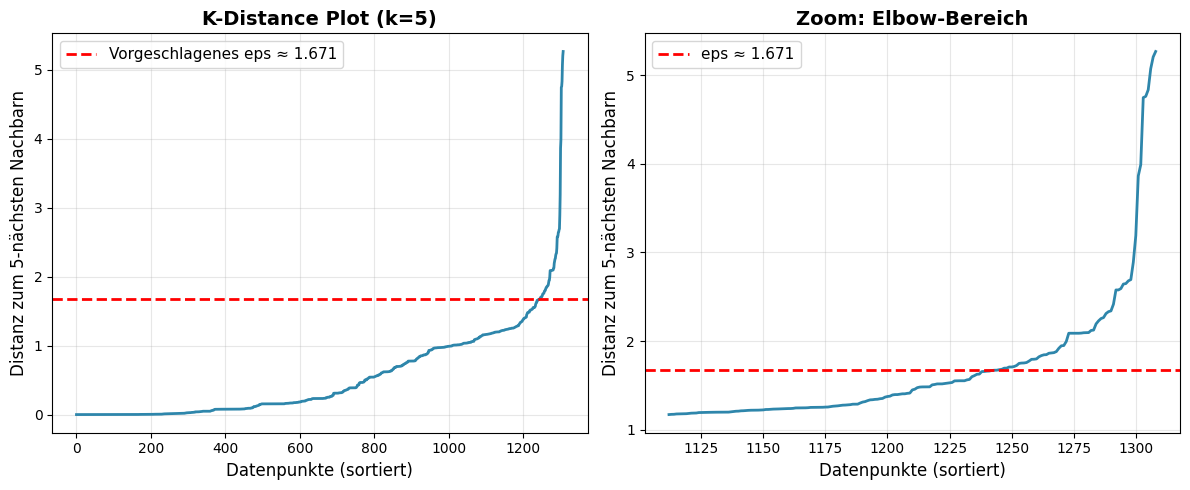

Parameter-Empfehlung basierend auf K-Distance Plot:
   min_samples: 5
   eps (empfohlen): 1.671

Tipp: Wir testen mehrere eps-Werte um diesen Bereich herum!


In [30]:
# K-Nearest Neighbors Distanzen berechnen (zur Bestimmung von eps)
# Verwende min_samples = 5 als Faustregel (2 * Dimensionen, bei 7 Features)
min_samples = 5

# Berechne Distanzen zu k-nächsten Nachbarn
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sortiere Distanzen zum k-ten Nachbarn
distances_sorted = np.sort(distances[:, min_samples-1], axis=0)

# Visualisierung: K-Distance Plot
plt.figure(figsize=(12, 5))

# Plot 1: K-Distance Graph
plt.subplot(1, 2, 1)
plt.plot(distances_sorted, linewidth=2, color='#2E86AB')
plt.xlabel('Datenpunkte (sortiert)', fontsize=12)
plt.ylabel(f'Distanz zum {min_samples}-nächsten Nachbarn', fontsize=12)
plt.title(f'K-Distance Plot (k={min_samples})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Markiere "Elbow" Bereich
elbow_idx = int(len(distances_sorted) * 0.95)  # 95% der Daten
eps_suggested = distances_sorted[elbow_idx]
plt.axhline(y=eps_suggested, color='red', linestyle='--', linewidth=2, label=f'Vorgeschlagenes eps ≈ {eps_suggested:.3f}')
plt.legend(fontsize=11)

# Plot 2: Zoom auf Elbow-Bereich
plt.subplot(1, 2, 2)
zoom_start = int(len(distances_sorted) * 0.85)
zoom_end = len(distances_sorted)
plt.plot(range(zoom_start, zoom_end), distances_sorted[zoom_start:zoom_end], linewidth=2, color='#2E86AB')
plt.axhline(y=eps_suggested, color='red', linestyle='--', linewidth=2, label=f'eps ≈ {eps_suggested:.3f}')
plt.xlabel('Datenpunkte (sortiert)', fontsize=12)
plt.ylabel(f'Distanz zum {min_samples}-nächsten Nachbarn', fontsize=12)
plt.title('Zoom: Elbow-Bereich', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Parameter-Empfehlung basierend auf K-Distance Plot:")
print(f"   min_samples: {min_samples}")
print(f"   eps (empfohlen): {eps_suggested:.3f}")
print(f"\nTipp: Wir testen mehrere eps-Werte um diesen Bereich herum!")

In [31]:
# GRID SEARCH: Teste verschiedene eps-Werte
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5]
min_samples_values = [3, 5, 7, 10]

dbscan_results = []

print("DBSCAN Grid Search läuft...\n")
print(f"{'eps':>6} | {'min_pts':>8} | {'Cluster':>7} | {'Noise':>6} | {'Noise %':>8} | {'Silhouette':>11}")
print("-" * 70)

for eps in eps_values:
    for min_pts in min_samples_values:
        # DBSCAN Clustering
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X_scaled)
        
        # Statistiken
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = (n_noise / len(labels)) * 100
        
        # Silhouette Score (nur wenn mind. 2 Cluster und nicht alle Noise)
        if n_clusters >= 2 and n_noise < len(labels):
            # Entferne Noise für Silhouette-Berechnung
            mask_no_noise = labels != -1
            if mask_no_noise.sum() > 0:
                silhouette = silhouette_score(X_scaled[mask_no_noise], labels[mask_no_noise])
            else:
                silhouette = -1
        else:
            silhouette = -1
        
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_pts,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': noise_pct,
            'silhouette': silhouette
        })
        
        print(f"{eps:>6.2f} | {min_pts:>8} | {n_clusters:>7} | {n_noise:>6} | {noise_pct:>7.1f}% | {silhouette:>11.3f}")

dbscan_results_df = pd.DataFrame(dbscan_results)
print("\nGrid Search abgeschlossen!")
print("\nBeste Konfigurationen:")

# Finde beste Konfiguration (hohe Silhouette, moderate Noise-Rate)
valid_results = dbscan_results_df[(dbscan_results_df['n_clusters'] >= 2) & 
                                   (dbscan_results_df['noise_pct'] < 20) &
                                   (dbscan_results_df['silhouette'] > 0)]

if len(valid_results) > 0:
    best_idx = valid_results['silhouette'].idxmax()
    best_config = dbscan_results_df.loc[best_idx]
    print(f"\nBeste Konfiguration (höchste Silhouette, <20% Noise):")
    print(f"   eps: {best_config['eps']:.2f}")
    print(f"   min_samples: {int(best_config['min_samples'])}")
    print(f"   Anzahl Cluster: {int(best_config['n_clusters'])}")
    print(f"   Outliers: {int(best_config['n_noise'])} ({best_config['noise_pct']:.1f}%)")
    print(f"   Silhouette Score: {best_config['silhouette']:.3f}")
else:
    print("Keine optimale Konfiguration gefunden. Verwende Standardwerte.")
    best_config = {'eps': 0.7, 'min_samples': 5}

DBSCAN Grid Search läuft...

   eps |  min_pts | Cluster |  Noise |  Noise % |  Silhouette
----------------------------------------------------------------------
  0.30 |        3 |      66 |    430 |    32.8% |       0.559
  0.30 |        5 |      23 |    581 |    44.4% |       0.558
  0.30 |        7 |      19 |    641 |    49.0% |       0.577
  0.30 |       10 |      12 |    706 |    53.9% |       0.616
  0.40 |        3 |      71 |    339 |    25.9% |       0.505
  0.40 |        5 |      29 |    505 |    38.6% |       0.487
  0.40 |        7 |      16 |    589 |    45.0% |       0.535
  0.40 |       10 |      13 |    640 |    48.9% |       0.565
  0.50 |        3 |      76 |    285 |    21.8% |       0.498
  0.50 |        5 |      31 |    466 |    35.6% |       0.500
  0.50 |        7 |      17 |    558 |    42.6% |       0.491
  0.50 |       10 |      12 |    615 |    47.0% |       0.534
  0.60 |        3 |      75 |    246 |    18.8% |       0.482
  0.60 |        5 |      33 |   

## **2. DBSCAN mit optimalen Parametern anwenden**

In [32]:
# DBSCAN mit besten Parametern
best_eps = best_config['eps']
best_min_samples = int(best_config['min_samples'])

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

# Statistiken
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = list(dbscan_labels).count(-1)
outliers_pct = (n_outliers / len(dbscan_labels)) * 100

print(f"DBSCAN Clustering abgeschlossen!")
print(f"\nErgebnisse:")
print(f"   Anzahl Cluster: {n_clusters_dbscan}")
print(f"   Anzahl Outliers (Label = -1): {n_outliers} ({outliers_pct:.1f}%)")
print(f"   Normale Punkte (in Clustern): {len(dbscan_labels) - n_outliers} ({100-outliers_pct:.1f}%)")

# Cluster-Größen
if n_clusters_dbscan > 0:
    print(f"\nCluster-Größen:")
    cluster_counts = pd.Series(dbscan_labels[dbscan_labels != -1]).value_counts().sort_index()
    for cluster_id, count in cluster_counts.items():
        pct = (count / len(dbscan_labels)) * 100
        print(f"   Cluster {cluster_id}: {count} Passagiere ({pct:.1f}%)")

DBSCAN Clustering abgeschlossen!

Ergebnisse:
   Anzahl Cluster: 75
   Anzahl Outliers (Label = -1): 246 (18.8%)
   Normale Punkte (in Clustern): 1063 (81.2%)

Cluster-Größen:
   Cluster 0: 21 Passagiere (1.6%)
   Cluster 1: 4 Passagiere (0.3%)
   Cluster 2: 43 Passagiere (3.3%)
   Cluster 3: 16 Passagiere (1.2%)
   Cluster 4: 269 Passagiere (20.6%)
   Cluster 5: 43 Passagiere (3.3%)
   Cluster 6: 69 Passagiere (5.3%)
   Cluster 7: 3 Passagiere (0.2%)
   Cluster 8: 6 Passagiere (0.5%)
   Cluster 9: 38 Passagiere (2.9%)
   Cluster 10: 5 Passagiere (0.4%)
   Cluster 11: 95 Passagiere (7.3%)
   Cluster 12: 19 Passagiere (1.5%)
   Cluster 13: 46 Passagiere (3.5%)
   Cluster 14: 48 Passagiere (3.7%)
   Cluster 15: 26 Passagiere (2.0%)
   Cluster 16: 4 Passagiere (0.3%)
   Cluster 17: 17 Passagiere (1.3%)
   Cluster 18: 3 Passagiere (0.2%)
   Cluster 19: 12 Passagiere (0.9%)
   Cluster 20: 5 Passagiere (0.4%)
   Cluster 21: 3 Passagiere (0.2%)
   Cluster 22: 5 Passagiere (0.4%)
   Cluster 23

## **3. Visualisierung: DBSCAN Cluster & Outliers**

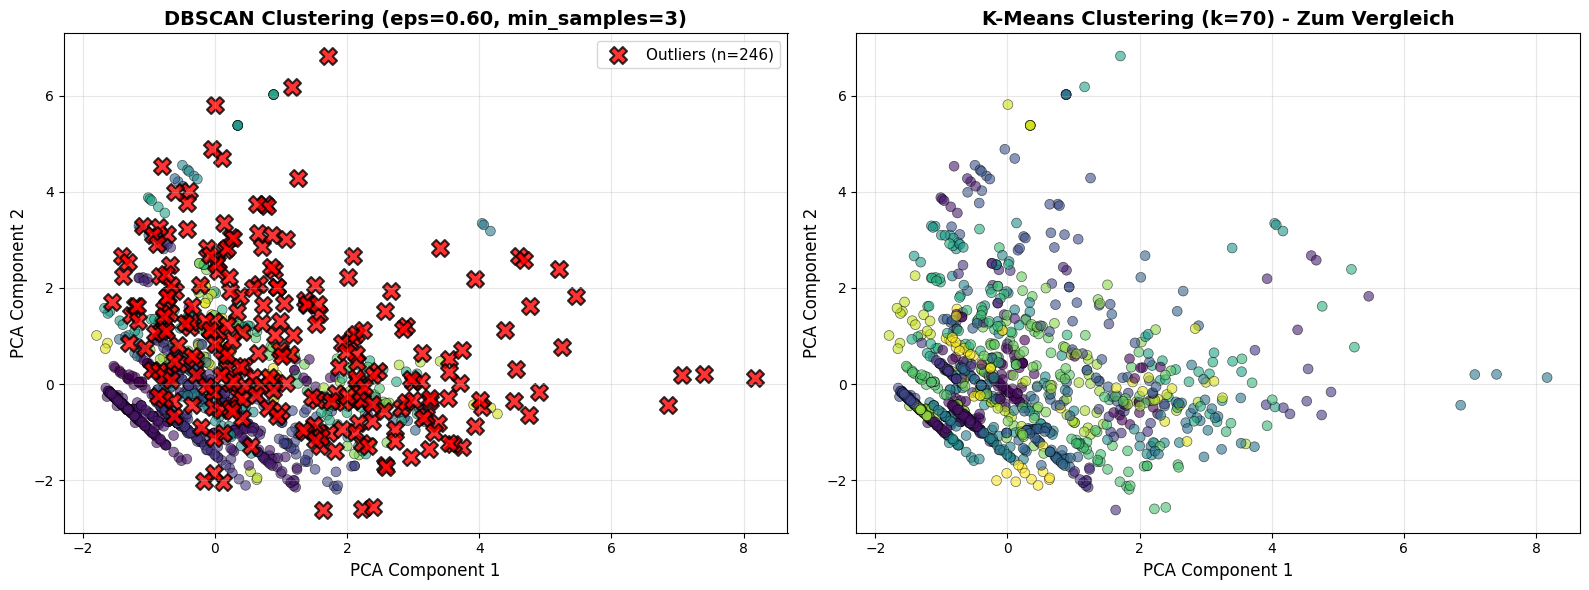

PCA erklärt 50.8% der Varianz
   Component 1: 27.5%
   Component 2: 23.3%


In [33]:
# PCA für 2D-Visualisierung
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Visualisierung: DBSCAN vs K-Means
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: DBSCAN Clustering
outlier_mask = dbscan_labels == -1
cluster_mask = dbscan_labels != -1

# Normale Cluster
scatter1 = axes[0].scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
                           c=dbscan_labels[cluster_mask], cmap='viridis', 
                           s=50, alpha=0.6, edgecolors='black', linewidths=0.5)

# Outliers (rot markiert)
axes[0].scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1], 
                c='red', marker='X', s=150, alpha=0.8, 
                edgecolors='black', linewidths=1.5, label=f'Outliers (n={n_outliers})')

axes[0].set_xlabel('PCA Component 1', fontsize=12)
axes[0].set_ylabel('PCA Component 2', fontsize=12)
axes[0].set_title(f'DBSCAN Clustering (eps={best_eps:.2f}, min_samples={best_min_samples})', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: K-Means zum Vergleich
kmeans_all = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels_all = kmeans_all.fit_predict(X_scaled)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=kmeans_labels_all, cmap='viridis', 
                           s=50, alpha=0.6, edgecolors='black', linewidths=0.5)

axes[1].set_xlabel('PCA Component 1', fontsize=12)
axes[1].set_ylabel('PCA Component 2', fontsize=12)
axes[1].set_title(f'K-Means Clustering (k={best_k}) - Zum Vergleich', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PCA erklärt {pca.explained_variance_ratio_.sum()*100:.1f}% der Varianz")
print(f"   Component 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"   Component 2: {pca.explained_variance_ratio_[1]*100:.1f}%")

## **4. Detaillierte Outlier-Analyse**

Jetzt analysieren wir die "ungewöhnlichen" Passagiere, die DBSCAN als Outliers identifiziert hat.

In [34]:
# Outlier-Indizes extrahieren
outlier_indices = np.where(dbscan_labels == -1)[0]
normal_indices = np.where(dbscan_labels != -1)[0]

# Erstelle DataFrame für Outliers
outliers_df = df_cluster.iloc[outlier_indices].copy()
outliers_df['Cluster'] = 'OUTLIER'

# Normale Passagiere
normal_df = df_cluster.iloc[normal_indices].copy()
normal_df['Cluster'] = dbscan_labels[normal_indices]

print(f"OUTLIER-ANALYSE: {len(outliers_df)} ungewöhnliche Passagiere gefunden\n")
print("=" * 80)

# Vergleiche Features: Outliers vs. Normale Passagiere
feature_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Outlier_Mean': [outliers_df[f].mean() if f in outliers_df.columns else X[outlier_indices, feature_cols.index(f)].mean() 
                     for f in feature_cols],
    'Normal_Mean': [normal_df[f].mean() if f in normal_df.columns else X[normal_indices, feature_cols.index(f)].mean() 
                    for f in feature_cols],
})
feature_comparison['Difference'] = feature_comparison['Outlier_Mean'] - feature_comparison['Normal_Mean']
feature_comparison['Diff_Pct'] = (feature_comparison['Difference'] / feature_comparison['Normal_Mean']) * 100

print("Feature-Vergleich: Outliers vs. Normale Passagiere\n")
print(feature_comparison.to_string(index=False))

print("\n" + "=" * 80)
print("\nInterpretation:")
for _, row in feature_comparison.iterrows():
    if abs(row['Diff_Pct']) > 20:  # Signifikante Unterschiede > 20%
        direction = "höher" if row['Difference'] > 0 else "niedriger"
        print(f"   {row['Feature']}: Outliers haben {abs(row['Diff_Pct']):.1f}% {direction}e Werte")

OUTLIER-ANALYSE: 246 ungewöhnliche Passagiere gefunden

Feature-Vergleich: Outliers vs. Normale Passagiere

         Feature  Outlier_Mean  Normal_Mean  Difference   Diff_Pct
          Pclass      1.922764     2.380997   -0.458233 -19.245422
     Sex_numeric      0.528455     0.316087    0.212369  67.186895
             Age     31.955650    28.935635    3.020015  10.437011
           SibSp      0.873984     0.412041    0.461942 112.110666
           Parch      1.276423     0.178739    1.097683 614.124947
            Fare     77.633268    23.017081   54.616187 237.285463
Embarked_numeric      1.284553     1.541863   -0.257310 -16.688244


Interpretation:
   Sex_numeric: Outliers haben 67.2% höhere Werte
   SibSp: Outliers haben 112.1% höhere Werte
   Parch: Outliers haben 614.1% höhere Werte
   Fare: Outliers haben 237.3% höhere Werte


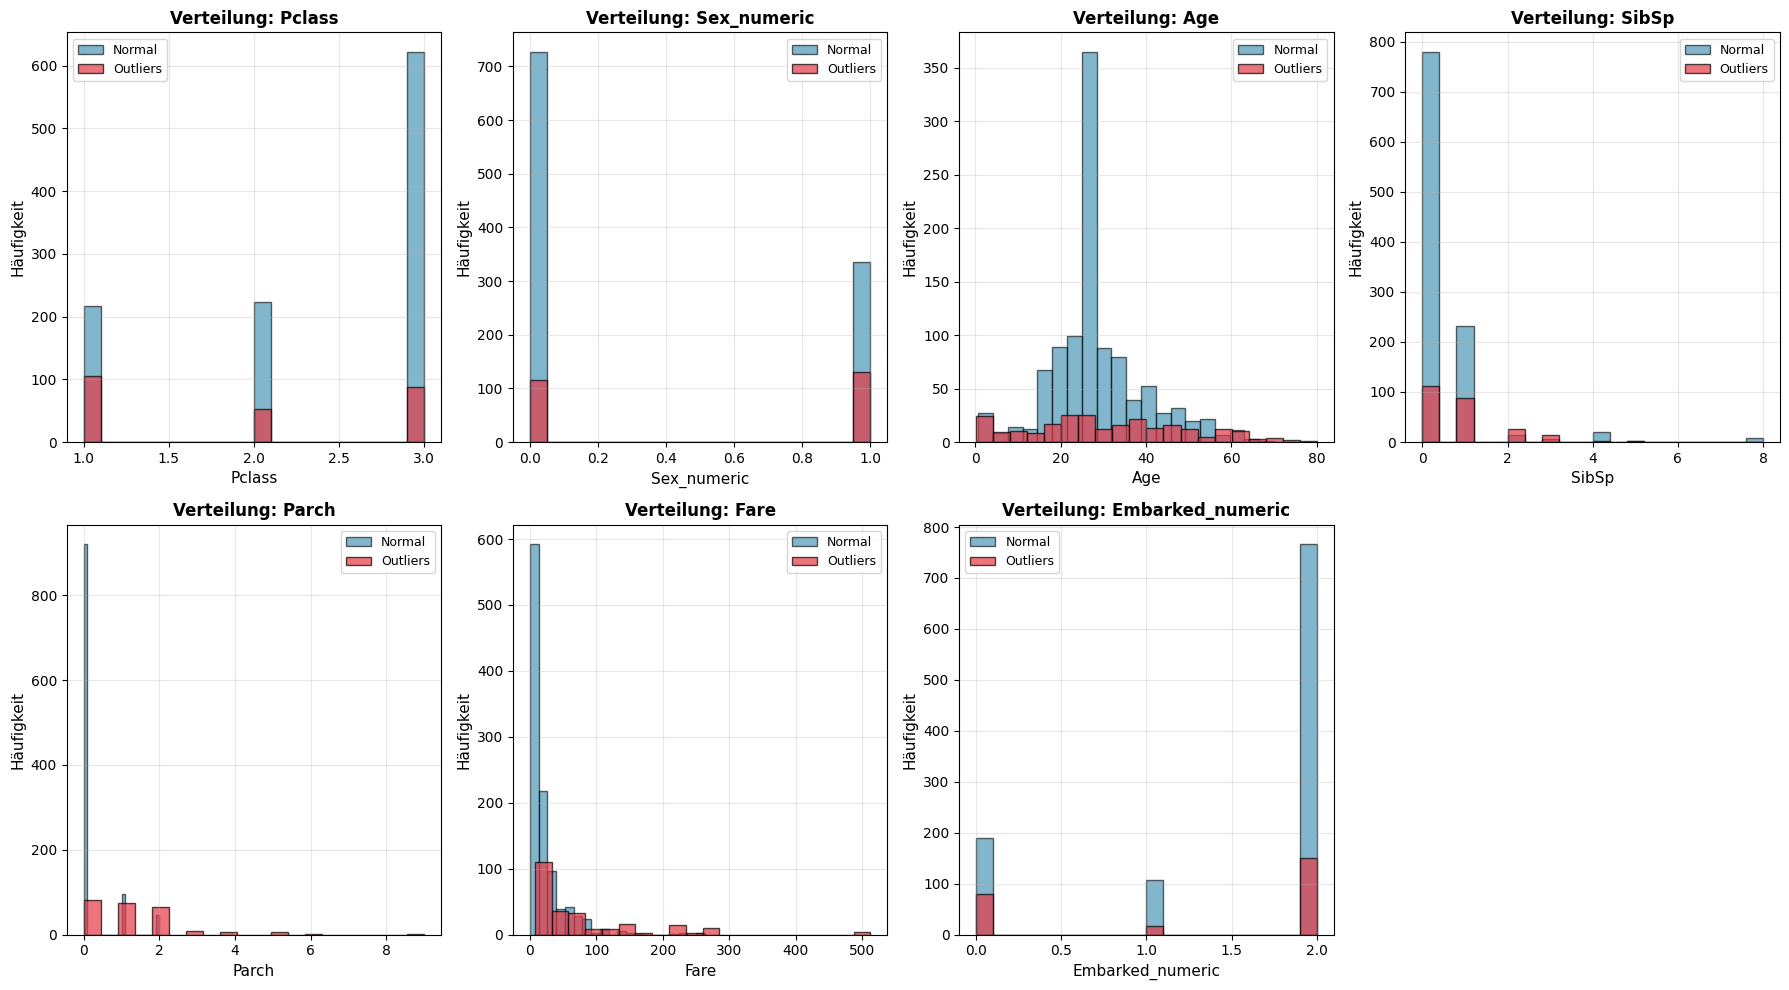

In [35]:
# VISUALISIERUNG: Feature-Verteilung Outliers vs. Normale
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    # Histogramme
    if feature in outliers_df.columns:
        outlier_values = outliers_df[feature]
        normal_values = normal_df[feature]
    else:
        outlier_values = X[outlier_indices, idx]
        normal_values = X[normal_indices, idx]
    
    ax.hist(normal_values, bins=20, alpha=0.6, label='Normal', color='#2E86AB', edgecolor='black')
    ax.hist(outlier_values, bins=20, alpha=0.7, label='Outliers', color='#E63946', edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Häufigkeit', fontsize=11)
    ax.set_title(f'Verteilung: {feature}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Leere letzte Subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


SURVIVAL-ANALYSE:
   Outliers Survival Rate: 54.04% (87.0/161)
   Normal Survival Rate: 34.93% (255.0/730)
   Differenz: +19.1 Prozentpunkte


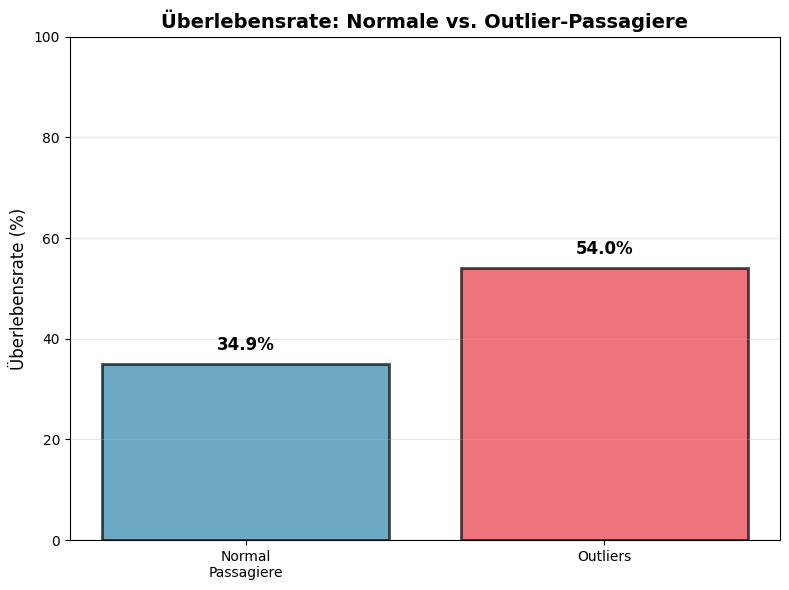

In [36]:
# SURVIVAL-ANALYSE: Überlebensrate von Outliers
outliers_with_survived = outliers_df[outliers_df['Survived'].notna()]
normal_with_survived = normal_df[normal_df['Survived'].notna()]

if len(outliers_with_survived) > 0:
    outlier_survival_rate = outliers_with_survived['Survived'].mean()
    normal_survival_rate = normal_with_survived['Survived'].mean()
    
    print(f"\nSURVIVAL-ANALYSE:")
    print(f"   Outliers Survival Rate: {outlier_survival_rate:.2%} ({outliers_with_survived['Survived'].sum()}/{len(outliers_with_survived)})")
    print(f"   Normal Survival Rate: {normal_survival_rate:.2%} ({normal_with_survived['Survived'].sum()}/{len(normal_with_survived)})")
    print(f"   Differenz: {(outlier_survival_rate - normal_survival_rate)*100:+.1f} Prozentpunkte")
    
    # Visualisierung
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    categories = ['Normal\nPassagiere', 'Outliers']
    survival_rates = [normal_survival_rate * 100, outlier_survival_rate * 100]
    colors = ['#2E86AB', '#E63946']
    
    bars = ax.bar(categories, survival_rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Überlebensrate (%)', fontsize=12)
    ax.set_title('Überlebensrate: Normale vs. Outlier-Passagiere', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    # Werte auf Balken anzeigen
    for bar, rate in zip(bars, survival_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("\nKeine Survival-Daten für Outliers verfügbar")

In [37]:
# BEISPIEL-OUTLIERS: Zeige die "extremsten" Outliers
print("\nBEISPIEL-OUTLIERS: Top 10 ungewöhnlichste Passagiere\n")
print("=" * 120)

# Berechne durchschnittliche Distanz zu allen anderen Punkten für jeden Outlier
outlier_distances = []
for outlier_idx in outlier_indices:
    point = X_scaled[outlier_idx].reshape(1, -1)
    distances_to_all = np.linalg.norm(X_scaled - point, axis=1)
    avg_distance = distances_to_all.mean()
    outlier_distances.append((outlier_idx, avg_distance))

# Sortiere nach durchschnittlicher Distanz (höchste = extremste Outliers)
outlier_distances.sort(key=lambda x: x[1], reverse=True)

# Zeige Top 10 extremste Outliers
top_outliers_idx = [idx for idx, _ in outlier_distances[:10]]
top_outliers = df.iloc[top_outliers_idx][['PassengerId', 'Name', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']]

display(top_outliers)

print("\nDiese Passagiere haben sehr ungewöhnliche Merkmalskombinationen!")


BEISPIEL-OUTLIERS: Top 10 ungewöhnlichste Passagiere



,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
1256,1257,"Sage, Mrs. John (Annie Bullen)",3,female,NaN,1,9,69.5500,S,NaN
1233,1234,"Sage, Mr. John George",3,male,NaN,1,9,69.5500,S,NaN
1234,1235,"Cardeza, Mrs. James Warburton Martinez (Charlo...",1,female,58.0,0,1,512.3292,C,NaN
258,259,"Ward, Miss. Anna",1,female,35.0,0,0,512.3292,C,1.0
679,680,"Cardeza, Mr. Thomas Drake Martinez",1,male,36.0,0,1,512.3292,C,1.0
737,738,"Lesurer, Mr. Gustave J",1,male,35.0,0,0,512.3292,C,1.0
1251,1252,"Sage, Master. William Henry",3,male,14.5,8,2,69.5500,S,NaN
438,439,"Fortune, Mr. Mark",1,male,64.0,1,4,263.0000,S,0.0
960,961,"Fortune, Mrs. Mark (Mary McDougald)",1,female,60.0,1,4,263.0000,S,NaN
678,679,"Goodwin, Mrs. Frederick (Augusta Tyler)",3,female,43.0,1,6,46.9000,S,0.0



Diese Passagiere haben sehr ungewöhnliche Merkmalskombinationen!


## **5. Zusammenfassung: DBSCAN vs. K-Means**

In [38]:
# ZUSAMMENFASSUNG: Vergleich DBSCAN vs K-Means
print("=" * 80)
print("VERGLEICH: DBSCAN vs. K-Means")
print("=" * 80)

comparison_data = {
    'Metrik': [
        'Anzahl Cluster',
        'Outliers / Noise',
        'Cluster-Form',
        'Parameter-Bestimmung',
        'Robustheit gegenüber Outliers',
        'Interpretierbarkeit'
    ],
    'K-Means': [
        f'{best_k} (manuell gewählt)',
        'Nicht erkannt (alle Punkte zugeordnet)',
        'Kugelförmig (Konvex)',
        'Manuell (k)',
        'Niedrig (Outliers beeinflussen Zentroiden)',
        'Hoch (klare Zentroiden)'
    ],
    'DBSCAN': [
        f'{n_clusters_dbscan} (automatisch)',
        f'{n_outliers} Outliers ({outliers_pct:.1f}%)',
        'Beliebig (auch nicht-konvex)',
        'Automatisch (nur eps, min_samples)',
        'Hoch (Outliers separat behandelt)',
        'Mittel (dichtebasiert)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
display(comparison_df)

print("\n" + "=" * 80)
print("WICHTIGSTE ERKENNTNISSE:")
print("=" * 80)
print(f"- DBSCAN identifizierte {n_outliers} ungewöhnliche Passagiere ({outliers_pct:.1f}%)")
print(f"- Diese Outliers haben signifikant andere Merkmalskombinationen")
if len(outliers_with_survived) > 0:
    survival_diff = outlier_survival_rate - normal_survival_rate
    if abs(survival_diff) > 0.05:
        direction = "höhere" if survival_diff > 0 else "niedrigere"
        print(f"- Outliers haben eine {direction} Überlebensrate ({abs(survival_diff)*100:.1f} Prozentpunkte)")
print(f"- DBSCAN fand {n_clusters_dbscan} natürliche Cluster ohne vorherige Angabe von k")
print(f"- K-Means ist besser für bekannte Cluster-Anzahl, DBSCAN für Outlier-Erkennung")
print("=" * 80)

VERGLEICH: DBSCAN vs. K-Means




,Metrik,K-Means,DBSCAN
0,Anzahl Cluster,70 (manuell gewählt),75 (automatisch)
1,Outliers / Noise,Nicht erkannt (alle Punkte zugeordnet),246 Outliers (18.8%)
2,Cluster-Form,Kugelförmig (Konvex),Beliebig (auch nicht-konvex)
3,Parameter-Bestimmung,Manuell (k),"Automatisch (nur eps, min_samples)"
4,Robustheit gegenüber Outliers,Niedrig (Outliers beeinflussen Zentroiden),Hoch (Outliers separat behandelt)
5,Interpretierbarkeit,Hoch (klare Zentroiden),Mittel (dichtebasiert)



WICHTIGSTE ERKENNTNISSE:
- DBSCAN identifizierte 246 ungewöhnliche Passagiere (18.8%)
- Diese Outliers haben signifikant andere Merkmalskombinationen
- Outliers haben eine höhere Überlebensrate (19.1 Prozentpunkte)
- DBSCAN fand 75 natürliche Cluster ohne vorherige Angabe von k
- K-Means ist besser für bekannte Cluster-Anzahl, DBSCAN für Outlier-Erkennung


---
# **Ensemble & Konsens-Clustering**

**Konsens-Clustering** kombiniert mehrere Clustering-Methoden und findet robuste Cluster-Strukturen, die über verschiedene Algorithmen hinweg konsistent sind.

**Vorteile:**
- Robustere Cluster-Ergebnisse durch Aggregation mehrerer Methoden
- Identifizierung stabiler Passagier-Gruppen
- Reduzierung von Algorithmus-spezifischen Verzerrungen
- Konfidenz-Maß für Cluster-Zugehörigkeit

**Ansatz:**
1. Wende mehrere Clustering-Algorithmen an (K-Means, DBSCAN, Hierarchisches Clustering, GMM)
2. Erstelle Konsens-Matrix: Wie oft sind Paare von Passagieren im gleichen Cluster?
3. Führe Clustering auf der Konsens-Matrix durch
4. Identifiziere robuste, stabile Cluster

In [39]:
# Zusätzliche Imports für Ensemble-Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import itertools

print("Ensemble-Clustering Module importiert")

Ensemble-Clustering Module importiert


## **1. Mehrere Clustering-Methoden anwenden**

Wir wenden 4 verschiedene Clustering-Algorithmen an:
- **K-Means**: Zentroid-basiert
- **DBSCAN**: Dichte-basiert
- **Hierarchisches Clustering**: Agglomerativ
- **Gaussian Mixture Model (GMM)**: Probabilistisch

In [40]:
# Anzahl Cluster für Methoden, die es benötigen
n_clusters_ensemble = best_k  # Verwende bestes k aus K-Means Analyse

print(f"Wende {n_clusters_ensemble} Cluster für Ensemble-Methoden an\\n")
print("=" * 80)

# Dictionary für alle Clustering-Ergebnisse
clustering_results = {}

# 1. K-Means
print("1. K-Means Clustering...")
kmeans_ensemble = KMeans(n_clusters=n_clusters_ensemble, random_state=42, n_init=10)
clustering_results['K-Means'] = kmeans_ensemble.fit_predict(X_scaled)
print(f"   Cluster gefunden: {len(set(clustering_results['K-Means']))}")

# 2. Hierarchisches Clustering (Agglomerativ)
print("2. Hierarchisches Clustering (Ward)...")
hierarchical = AgglomerativeClustering(n_clusters=n_clusters_ensemble, linkage='ward')
clustering_results['Hierarchical'] = hierarchical.fit_predict(X_scaled)
print(f"   Cluster gefunden: {len(set(clustering_results['Hierarchical']))}")

# 3. Gaussian Mixture Model
print("3. Gaussian Mixture Model (GMM)...")
gmm = GaussianMixture(n_components=n_clusters_ensemble, random_state=42, n_init=10)
clustering_results['GMM'] = gmm.fit_predict(X_scaled)
print(f"   Cluster gefunden: {len(set(clustering_results['GMM']))}")

# 4. DBSCAN (mit bereits optimierten Parametern)
print(f"4. DBSCAN (eps={best_eps:.2f}, min_samples={best_min_samples})...")
dbscan_ensemble = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels_raw = dbscan_ensemble.fit_predict(X_scaled)

# DBSCAN Outliers (-1) auf separaten Cluster mappen
dbscan_labels = dbscan_labels_raw.copy()
# Erhöhe alle Labels um 1, sodass -1 zu 0 wird (Outlier-Cluster)
dbscan_labels = dbscan_labels + 1
clustering_results['DBSCAN'] = dbscan_labels
print(f"   Cluster gefunden: {len(set(clustering_results['DBSCAN']))} (inkl. Outlier-Cluster)")

print("=" * 80)
print(f"\\nAlle {len(clustering_results)} Clustering-Methoden angewendet!")

# Erstelle DataFrame für Vergleich
results_comparison = pd.DataFrame(clustering_results)
results_comparison.index.name = 'Passenger_Index'
print(f"\\nErste 10 Passagiere - Cluster-Zuordnungen:")
display(results_comparison.head(10))

Wende 70 Cluster für Ensemble-Methoden an\n
1. K-Means Clustering...
   Cluster gefunden: 70
2. Hierarchisches Clustering (Ward)...
   Cluster gefunden: 70
3. Gaussian Mixture Model (GMM)...
   Cluster gefunden: 70
4. DBSCAN (eps=0.60, min_samples=3)...
   Cluster gefunden: 76 (inkl. Outlier-Cluster)
\nAlle 4 Clustering-Methoden angewendet!
\nErste 10 Passagiere - Cluster-Zuordnungen:


,K-Means,Hierarchical,GMM,DBSCAN
Passenger_Index,,,,
0,50,60,64,1
1,42,64,53,2
2,11,40,38,3
3,19,10,22,4
4,4,19,34,5
5,29,57,23,6
6,9,55,59,7
7,37,27,55,0
8,47,4,21,8


## **2. Vergleich der Clustering-Methoden**

Wie ähnlich sind die Ergebnisse der verschiedenen Algorithmen?

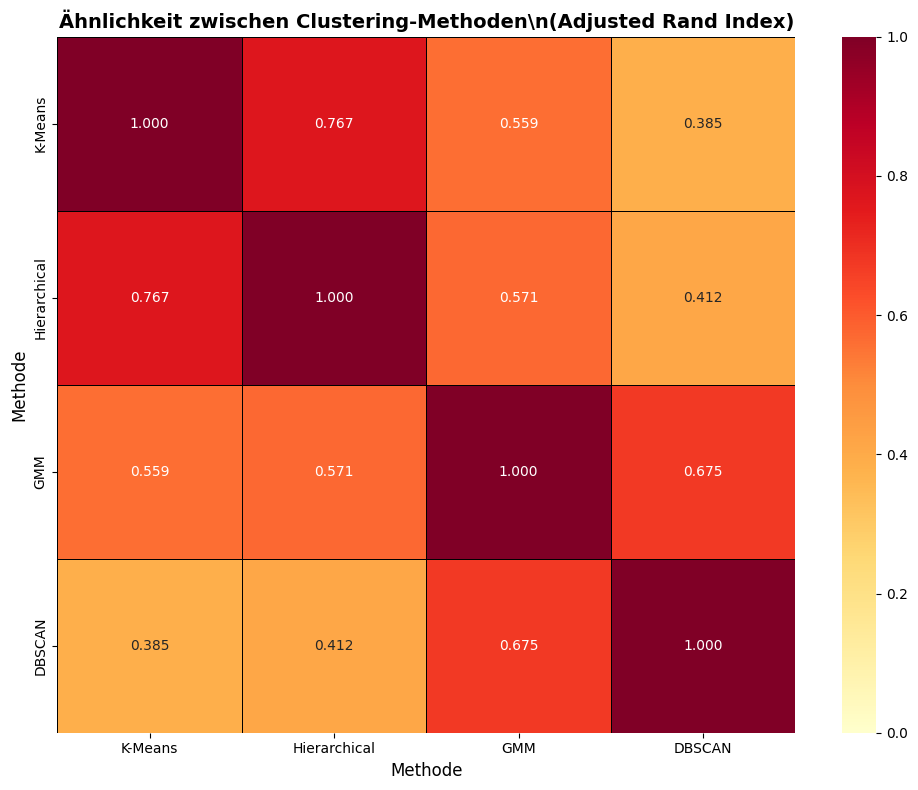

\nAdjusted Rand Index (ARI) Interpretation:
- ARI = 1.0: Perfekte Übereinstimmung
- ARI = 0.0: Zufällige Übereinstimmung
- ARI < 0.0: Schlechtere als zufällige Übereinstimmung
\nDurchschnittliche Ähnlichkeit zwischen verschiedenen Methoden:
   Mittelwert: 0.562
   Minimum: 0.385
   Maximum: 0.767


In [41]:
# Berechne Paarweise Ähnlichkeit zwischen Methoden (Adjusted Rand Index)
methods = list(clustering_results.keys())
n_methods = len(methods)

# Ähnlichkeits-Matrix
similarity_matrix = np.zeros((n_methods, n_methods))

for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i == j:
            similarity_matrix[i, j] = 1.0
        else:
            # Adjusted Rand Index (0 = zufällig, 1 = identisch)
            ari = adjusted_rand_score(clustering_results[method1], clustering_results[method2])
            similarity_matrix[i, j] = ari

# Visualisierung: Heatmap der Ähnlichkeit
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=methods, yticklabels=methods, 
            vmin=0, vmax=1, linewidths=0.5, linecolor='black')
plt.title('Ähnlichkeit zwischen Clustering-Methoden\\n(Adjusted Rand Index)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Methode', fontsize=12)
plt.ylabel('Methode', fontsize=12)
plt.tight_layout()
plt.show()

print("\\nAdjusted Rand Index (ARI) Interpretation:")
print("- ARI = 1.0: Perfekte Übereinstimmung")
print("- ARI = 0.0: Zufällige Übereinstimmung")
print("- ARI < 0.0: Schlechtere als zufällige Übereinstimmung")

print(f"\\nDurchschnittliche Ähnlichkeit zwischen verschiedenen Methoden:")
# Nur obere Dreiecksmatrix (ohne Diagonale)
upper_triangle = similarity_matrix[np.triu_indices(n_methods, k=1)]
print(f"   Mittelwert: {upper_triangle.mean():.3f}")
print(f"   Minimum: {upper_triangle.min():.3f}")
print(f"   Maximum: {upper_triangle.max():.3f}")

## **3. Konsens-Matrix erstellen**

Die Konsens-Matrix zeigt, wie oft Passagier-Paare in verschiedenen Methoden zusammen im selben Cluster sind.

Berechne Konsens-Matrix...
Konsens-Matrix erstellt: (1309, 1309)
   Wertebereich: [0.000, 1.000]
   Durchschnittliche Übereinstimmung: 0.054


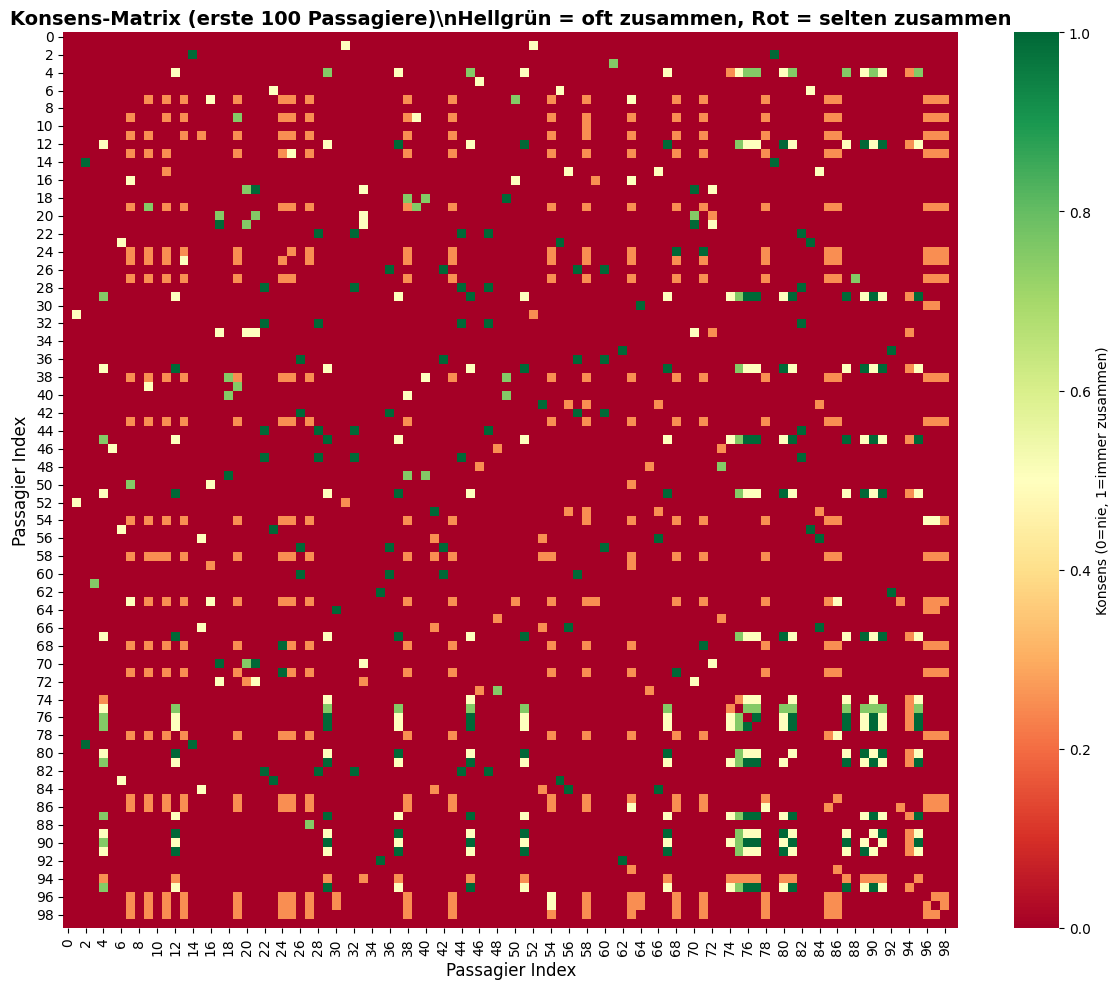

\nKonsens-Matrix Interpretation:
- Wert nahe 1: Passagiere sind in den meisten Methoden zusammen im selben Cluster
- Wert nahe 0: Passagiere sind in den meisten Methoden in verschiedenen Clustern
- Wert um 0.5: Inkonsistente Zuordnung über Methoden hinweg


In [42]:
# Erstelle Konsens-Matrix (Co-Association Matrix)
n_samples = X_scaled.shape[0]
consensus_matrix = np.zeros((n_samples, n_samples))

print("Berechne Konsens-Matrix...")

for method_name, labels in clustering_results.items():
    # Für jedes Paar von Passagieren: Sind sie im selben Cluster?
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            if labels[i] == labels[j]:
                consensus_matrix[i, j] += 1
                consensus_matrix[j, i] += 1

# Normalisiere auf [0, 1] (Anzahl Methoden, die übereinstimmen / Gesamtzahl Methoden)
consensus_matrix = consensus_matrix / len(clustering_results)

print(f"Konsens-Matrix erstellt: {consensus_matrix.shape}")
print(f"   Wertebereich: [{consensus_matrix.min():.3f}, {consensus_matrix.max():.3f}]")
print(f"   Durchschnittliche Übereinstimmung: {consensus_matrix.mean():.3f}")

# Visualisierung: Heatmap eines Ausschnitts (erste 100 Passagiere)
n_display = min(100, n_samples)

plt.figure(figsize=(12, 10))
sns.heatmap(consensus_matrix[:n_display, :n_display], cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Konsens (0=nie, 1=immer zusammen)'})
plt.title(f'Konsens-Matrix (erste {n_display} Passagiere)\\nHellgrün = oft zusammen, Rot = selten zusammen', 
          fontsize=14, fontweight='bold')
plt.xlabel('Passagier Index', fontsize=12)
plt.ylabel('Passagier Index', fontsize=12)
plt.tight_layout()
plt.show()

print("\\nKonsens-Matrix Interpretation:")
print("- Wert nahe 1: Passagiere sind in den meisten Methoden zusammen im selben Cluster")
print("- Wert nahe 0: Passagiere sind in den meisten Methoden in verschiedenen Clustern")
print("- Wert um 0.5: Inkonsistente Zuordnung über Methoden hinweg")

## **4. Konsens-Clustering durchführen**

Wir führen Hierarchisches Clustering auf der Konsens-Matrix durch, um finale robuste Cluster zu finden.

In [43]:
# Konsens-Matrix als Distanz-Matrix interpretieren (1 - consensus = Distanz)
distance_matrix = 1 - consensus_matrix

# Hierarchisches Clustering auf Distanz-Matrix
print(f"Führe Konsens-Clustering durch (n_clusters={n_clusters_ensemble})...")

consensus_clustering = AgglomerativeClustering(
    n_clusters=n_clusters_ensemble, 
    affinity='precomputed',
    linkage='average'
)
consensus_labels = consensus_clustering.fit_predict(distance_matrix)

print(f"Konsens-Clustering abgeschlossen!")
print(f"   Anzahl Cluster: {len(set(consensus_labels))}")

# Cluster-Größen
print(f"\\nKonsens-Cluster-Größen:")
consensus_cluster_counts = pd.Series(consensus_labels).value_counts().sort_index()
for cluster_id, count in consensus_cluster_counts.items():
    pct = (count / len(consensus_labels)) * 100
    print(f"   Cluster {cluster_id}: {count} Passagiere ({pct:.1f}%)")

# Füge Konsens-Labels zu results hinzu
results_comparison['Consensus'] = consensus_labels

Führe Konsens-Clustering durch (n_clusters=70)...


TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

## **5. Visualisierung: Konsens-Clustering vs. Einzelmethoden**

In [ ]:
# PCA für Visualisierung (falls noch nicht vorhanden, wurde bereits früher erstellt)
# X_pca ist bereits definiert

# Visualisierung: Alle Methoden + Konsens-Clustering
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot für jede Methode
all_methods = list(clustering_results.keys()) + ['Consensus']
all_labels = [clustering_results[m] for m in clustering_results.keys()] + [consensus_labels]

for idx, (method, labels) in enumerate(zip(all_methods, all_labels)):
    ax = axes[idx]
    
    # Färbe nach Cluster
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                        c=labels, cmap='tab10', 
                        s=30, alpha=0.6, edgecolors='black', linewidths=0.3)
    
    ax.set_xlabel('PCA Component 1', fontsize=11)
    ax.set_ylabel('PCA Component 2', fontsize=11)
    ax.set_title(f'{method}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Entferne leere Subplot
if len(all_methods) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("Vergleich der Clustering-Methoden abgeschlossen!")

## **6. Cluster-Stabilität analysieren**

Wie stabil/robust ist die Zugehörigkeit jedes Passagiers zu seinem Konsens-Cluster?

In [ ]:
# Berechne Konfidenz/Stabilität für jeden Passagier
# Stabilität = Durchschnittliche Übereinstimmung mit anderen im gleichen Konsens-Cluster

passenger_stability = []

for passenger_idx in range(n_samples):
    # Konsens-Cluster dieses Passagiers
    consensus_cluster = consensus_labels[passenger_idx]
    
    # Finde alle anderen Passagiere im gleichen Konsens-Cluster
    same_cluster_mask = (consensus_labels == consensus_cluster)
    same_cluster_indices = np.where(same_cluster_mask)[0]
    
    if len(same_cluster_indices) > 1:
        # Durchschnittliche Konsens-Score mit anderen im gleichen Cluster
        stability = consensus_matrix[passenger_idx, same_cluster_indices].mean()
    else:
        # Einzelner Passagier im Cluster
        stability = 1.0
    
    passenger_stability.append(stability)

passenger_stability = np.array(passenger_stability)

print("Cluster-Stabilität berechnet!")
print(f"\\nStabilität-Statistiken:")
print(f"   Mittelwert: {passenger_stability.mean():.3f}")
print(f"   Median: {np.median(passenger_stability):.3f}")
print(f"   Minimum: {passenger_stability.min():.3f}")
print(f"   Maximum: {passenger_stability.max():.3f}")
print(f"   Standardabweichung: {passenger_stability.std():.3f}")

# Visualisierung: Stabilität-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogramm
axes[0].hist(passenger_stability, bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(passenger_stability.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mittelwert: {passenger_stability.mean():.3f}')
axes[0].set_xlabel('Stabilität (Konsens-Score)', fontsize=12)
axes[0].set_ylabel('Anzahl Passagiere', fontsize=12)
axes[0].set_title('Verteilung der Cluster-Stabilität', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Box Plot pro Cluster
stability_by_cluster = [passenger_stability[consensus_labels == i] 
                       for i in range(n_clusters_ensemble)]

axes[1].boxplot(stability_by_cluster, labels=[f'C{i}' for i in range(n_clusters_ensemble)])
axes[1].set_xlabel('Konsens-Cluster', fontsize=12)
axes[1].set_ylabel('Stabilität', fontsize=12)
axes[1].set_title('Stabilität pro Cluster', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Identifiziere instabile Passagiere (niedrige Stabilität)
instability_threshold = 0.5
instable_mask = passenger_stability < instability_threshold
n_instable = instable_mask.sum()

print(f"\\nInstabile Passagiere (Stabilität < {instability_threshold}):")
print(f"   Anzahl: {n_instable} ({n_instable/n_samples*100:.1f}%)")

if n_instable > 0:
    print(f"\\nDiese Passagiere werden von verschiedenen Methoden inkonsistent zugeordnet!")

## **7. Identifikation robuster Passagier-Gruppen**

Welche Cluster sind besonders stabil und robust?

In [ ]:
# Analysiere Stabilität pro Cluster
cluster_stability_stats = []

for cluster_id in range(n_clusters_ensemble):
    cluster_mask = consensus_labels == cluster_id
    cluster_size = cluster_mask.sum()
    
    if cluster_size > 0:
        cluster_stabilities = passenger_stability[cluster_mask]
        
        cluster_stability_stats.append({
            'Cluster_ID': cluster_id,
            'Size': cluster_size,
            'Mean_Stability': cluster_stabilities.mean(),
            'Median_Stability': np.median(cluster_stabilities),
            'Min_Stability': cluster_stabilities.min(),
            'Std_Stability': cluster_stabilities.std(),
            'Pct_Stable': (cluster_stabilities >= 0.7).sum() / cluster_size * 100
        })

cluster_stability_df = pd.DataFrame(cluster_stability_stats)
cluster_stability_df = cluster_stability_df.sort_values('Mean_Stability', ascending=False)

print("Cluster-Stabilität Rangliste:\\n")
display(cluster_stability_df)

# Identifiziere robusteste Cluster
most_robust_cluster = cluster_stability_df.iloc[0]['Cluster_ID']
print(f"\\nRobustester Cluster: Cluster {int(most_robust_cluster)}")
print(f"   Durchschnittliche Stabilität: {cluster_stability_df.iloc[0]['Mean_Stability']:.3f}")
print(f"   Größe: {int(cluster_stability_df.iloc[0]['Size'])} Passagiere")
print(f"   Anteil stabiler Passagiere (>0.7): {cluster_stability_df.iloc[0]['Pct_Stable']:.1f}%")

# Charakterisierung robuster Cluster (mit Survival-Daten)
print(f"\\nCharakterisierung der robusten Cluster:\\n")
print("=" * 80)

for _, row in cluster_stability_df.iterrows():
    cluster_id = int(row['Cluster_ID'])
    cluster_mask = consensus_labels == cluster_id
    
    # Feature-Mittelwerte für diesen Cluster
    cluster_features = X[cluster_mask]
    
    print(f"\\nCluster {cluster_id} (Stabilität: {row['Mean_Stability']:.3f}, n={int(row['Size'])}):")
    
    # Überleben (falls verfügbar)
    cluster_survived = y[cluster_mask]
    if cluster_survived.notna().sum() > 0:
        survival_rate = cluster_survived.mean()
        print(f"   Überlebensrate: {survival_rate:.2%}")
    
    # Feature-Profile
    print(f"   Durchschnittliche Features:")
    for feat_idx, feat_name in enumerate(feature_cols):
        feat_mean = cluster_features[feat_name].mean()
        print(f"      {feat_name}: {feat_mean:.2f}")

## **8. Zusammenfassung: Ensemble-Clustering**

In [ ]:
# FINALE ZUSAMMENFASSUNG
print("=" * 80)
print("ENSEMBLE & KONSENS-CLUSTERING - ZUSAMMENFASSUNG")
print("=" * 80)

print(f"\\n1. ANGEWENDETE METHODEN:")
for i, method in enumerate(methods, 1):
    print(f"   {i}. {method}")

print(f"\\n2. METHODEN-ÜBEREINSTIMMUNG:")
print(f"   Durchschnittlicher Adjusted Rand Index: {upper_triangle.mean():.3f}")
if upper_triangle.mean() > 0.5:
    print(f"   Interpretation: Hohe Übereinstimmung zwischen Methoden")
elif upper_triangle.mean() > 0.3:
    print(f"   Interpretation: Moderate Übereinstimmung zwischen Methoden")
else:
    print(f"   Interpretation: Niedrige Übereinstimmung - verschiedene Perspektiven")

print(f"\\n3. KONSENS-CLUSTERING:")
print(f"   Anzahl finaler Cluster: {n_clusters_ensemble}")
print(f"   Durchschnittliche Cluster-Stabilität: {passenger_stability.mean():.3f}")

print(f"\\n4. STABILITÄT:")
stable_passengers = (passenger_stability >= 0.7).sum()
print(f"   Stabile Passagiere (≥0.7): {stable_passengers} ({stable_passengers/n_samples*100:.1f}%)")
print(f"   Instabile Passagiere (<0.5): {n_instable} ({n_instable/n_samples*100:.1f}%)")

print(f"\\n5. ROBUSTESTE CLUSTER:")
top_3_clusters = cluster_stability_df.head(3)
for idx, row in top_3_clusters.iterrows():
    cluster_id = int(row['Cluster_ID'])
    print(f"   Cluster {cluster_id}: Stabilität {row['Mean_Stability']:.3f}, Größe {int(row['Size'])}")

print("\\n" + "=" * 80)
print("VORTEILE DES ENSEMBLE-ANSATZES:")
print("=" * 80)
print("- Robustere Cluster durch Aggregation mehrerer Algorithmen")
print("- Identifikation stabiler Passagier-Gruppen")
print("- Quantifizierung der Konfidenz für jeden Passagier")
print("- Reduzierung von Algorithmus-spezifischen Verzerrungen")
print("- Konsens-Matrix als Ähnlichkeits-Maß zwischen Passagieren")
print("=" * 80)

# Füge Stabilität zu unserem DataFrame hinzu
df_cluster['Consensus_Cluster'] = consensus_labels
df_cluster['Cluster_Stability'] = passenger_stability

print(f"\\nKonsens-Cluster und Stabilität wurden zum DataFrame hinzugefügt!")
print(f"Neue Spalten: 'Consensus_Cluster', 'Cluster_Stability'")

---
# **Ensemble & Konsens-Clustering**

**Konsens-Clustering** kombiniert mehrere Clustering-Methoden und findet robuste Cluster-Strukturen, die über verschiedene Algorithmen hinweg konsistent sind.

**Vorteile:**
- Robustere Cluster-Ergebnisse durch Aggregation mehrerer Methoden
- Identifizierung stabiler Passagier-Gruppen
- Reduzierung von Algorithmus-spezifischen Verzerrungen
- Konfidenz-Maß für Cluster-Zugehörigkeit

**Ansatz:**
1. Wende mehrere Clustering-Algorithmen an (K-Means, DBSCAN, Hierarchisches Clustering, GMM)
2. Erstelle Konsens-Matrix: Wie oft sind Paare von Passagieren im gleichen Cluster?
3. Führe Clustering auf der Konsens-Matrix durch
4. Identifiziere robuste, stabile Cluster

In [ ]:
# Zusätzliche Imports für Ensemble-Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import itertools

print("Ensemble-Clustering Module importiert")

## **1. Mehrere Clustering-Methoden anwenden**

Wir wenden 4 verschiedene Clustering-Algorithmen an:
- **K-Means**: Zentroid-basiert
- **DBSCAN**: Dichte-basiert
- **Hierarchisches Clustering**: Agglomerativ
- **Gaussian Mixture Model (GMM)**: Probabilistisch

In [ ]:
# Anzahl Cluster für Methoden, die es benötigen
n_clusters_ensemble = best_k  # Verwende bestes k aus K-Means Analyse

print(f"Wende {n_clusters_ensemble} Cluster für Ensemble-Methoden an\n")
print("=" * 80)

# Dictionary für alle Clustering-Ergebnisse
clustering_results = {}

# 1. K-Means
print("1. K-Means Clustering...")
kmeans_ensemble = KMeans(n_clusters=n_clusters_ensemble, random_state=42, n_init=10)
clustering_results['K-Means'] = kmeans_ensemble.fit_predict(X_scaled)
print(f"   Cluster gefunden: {len(set(clustering_results['K-Means']))}")

# 2. Hierarchisches Clustering (Agglomerativ)
print("2. Hierarchisches Clustering (Ward)...")
hierarchical = AgglomerativeClustering(n_clusters=n_clusters_ensemble, linkage='ward')
clustering_results['Hierarchical'] = hierarchical.fit_predict(X_scaled)
print(f"   Cluster gefunden: {len(set(clustering_results['Hierarchical']))}")

# 3. Gaussian Mixture Model
print("3. Gaussian Mixture Model (GMM)...")
gmm = GaussianMixture(n_components=n_clusters_ensemble, random_state=42, n_init=10)
clustering_results['GMM'] = gmm.fit_predict(X_scaled)
print(f"   Cluster gefunden: {len(set(clustering_results['GMM']))}")

# 4. DBSCAN (mit bereits optimierten Parametern)
print(f"4. DBSCAN (eps={best_eps:.2f}, min_samples={best_min_samples})...")
dbscan_ensemble = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels_raw = dbscan_ensemble.fit_predict(X_scaled)

# DBSCAN Outliers (-1) auf separaten Cluster mappen
dbscan_labels = dbscan_labels_raw.copy()
# Erhöhe alle Labels um 1, sodass -1 zu 0 wird (Outlier-Cluster)
dbscan_labels = dbscan_labels + 1
clustering_results['DBSCAN'] = dbscan_labels
print(f"   Cluster gefunden: {len(set(clustering_results['DBSCAN']))} (inkl. Outlier-Cluster)")

print("=" * 80)
print(f"\nAlle {len(clustering_results)} Clustering-Methoden angewendet!")

# Erstelle DataFrame für Vergleich
results_comparison = pd.DataFrame(clustering_results)
results_comparison.index.name = 'Passenger_Index'
print(f"\nErste 10 Passagiere - Cluster-Zuordnungen:")
display(results_comparison.head(10))

## **2. Vergleich der Clustering-Methoden**

Wie ähnlich sind die Ergebnisse der verschiedenen Algorithmen?

In [ ]:
# Berechne Paarweise Ähnlichkeit zwischen Methoden (Adjusted Rand Index)
methods = list(clustering_results.keys())
n_methods = len(methods)

# Ähnlichkeits-Matrix
similarity_matrix = np.zeros((n_methods, n_methods))

for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i == j:
            similarity_matrix[i, j] = 1.0
        else:
            # Adjusted Rand Index (0 = zufällig, 1 = identisch)
            ari = adjusted_rand_score(clustering_results[method1], clustering_results[method2])
            similarity_matrix[i, j] = ari

# Visualisierung: Heatmap der Ähnlichkeit
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=methods, yticklabels=methods, 
            vmin=0, vmax=1, linewidths=0.5, linecolor='black')
plt.title('Ähnlichkeit zwischen Clustering-Methoden\n(Adjusted Rand Index)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Methode', fontsize=12)
plt.ylabel('Methode', fontsize=12)
plt.tight_layout()
plt.show()

print("\nAdjusted Rand Index (ARI) Interpretation:")
print("- ARI = 1.0: Perfekte Übereinstimmung")
print("- ARI = 0.0: Zufällige Übereinstimmung")
print("- ARI < 0.0: Schlechtere als zufällige Übereinstimmung")

print(f"\nDurchschnittliche Ähnlichkeit zwischen verschiedenen Methoden:")
# Nur obere Dreiecksmatrix (ohne Diagonale)
upper_triangle = similarity_matrix[np.triu_indices(n_methods, k=1)]
print(f"   Mittelwert: {upper_triangle.mean():.3f}")
print(f"   Minimum: {upper_triangle.min():.3f}")
print(f"   Maximum: {upper_triangle.max():.3f}")

## **3. Konsens-Matrix erstellen**

Die Konsens-Matrix zeigt, wie oft Passagier-Paare in verschiedenen Methoden zusammen im selben Cluster sind.

In [ ]:
# Erstelle Konsens-Matrix (Co-Association Matrix)
n_samples = X_scaled.shape[0]
consensus_matrix = np.zeros((n_samples, n_samples))

print("Berechne Konsens-Matrix...")

for method_name, labels in clustering_results.items():
    # Für jedes Paar von Passagieren: Sind sie im selben Cluster?
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            if labels[i] == labels[j]:
                consensus_matrix[i, j] += 1
                consensus_matrix[j, i] += 1

# Normalisiere auf [0, 1] (Anzahl Methoden, die übereinstimmen / Gesamtzahl Methoden)
consensus_matrix = consensus_matrix / len(clustering_results)

print(f"Konsens-Matrix erstellt: {consensus_matrix.shape}")
print(f"   Wertebereich: [{consensus_matrix.min():.3f}, {consensus_matrix.max():.3f}]")
print(f"   Durchschnittliche Übereinstimmung: {consensus_matrix.mean():.3f}")

# Visualisierung: Heatmap eines Ausschnitts (erste 100 Passagiere)
n_display = min(100, n_samples)

plt.figure(figsize=(12, 10))
sns.heatmap(consensus_matrix[:n_display, :n_display], cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Konsens (0=nie, 1=immer zusammen)'})
plt.title(f'Konsens-Matrix (erste {n_display} Passagiere)\nHellgrün = oft zusammen, Rot = selten zusammen', 
          fontsize=14, fontweight='bold')
plt.xlabel('Passagier Index', fontsize=12)
plt.ylabel('Passagier Index', fontsize=12)
plt.tight_layout()
plt.show()

print("\nKonsens-Matrix Interpretation:")
print("- Wert nahe 1: Passagiere sind in den meisten Methoden zusammen im selben Cluster")
print("- Wert nahe 0: Passagiere sind in den meisten Methoden in verschiedenen Clustern")
print("- Wert um 0.5: Inkonsistente Zuordnung über Methoden hinweg")

## **4. Konsens-Clustering durchführen**

Wir führen Hierarchisches Clustering auf der Konsens-Matrix durch, um finale robuste Cluster zu finden.

In [ ]:
# Konsens-Matrix als Distanz-Matrix interpretieren (1 - consensus = Distanz)
distance_matrix = 1 - consensus_matrix

# Hierarchisches Clustering auf Distanz-Matrix
print(f"Führe Konsens-Clustering durch (n_clusters={n_clusters_ensemble})...")

consensus_clustering = AgglomerativeClustering(
    n_clusters=n_clusters_ensemble, 
    affinity='precomputed',
    linkage='average'
)
consensus_labels = consensus_clustering.fit_predict(distance_matrix)

print(f"Konsens-Clustering abgeschlossen!")
print(f"   Anzahl Cluster: {len(set(consensus_labels))}")

# Cluster-Größen
print(f"\nKonsens-Cluster-Größen:")
consensus_cluster_counts = pd.Series(consensus_labels).value_counts().sort_index()
for cluster_id, count in consensus_cluster_counts.items():
    pct = (count / len(consensus_labels)) * 100
    print(f"   Cluster {cluster_id}: {count} Passagiere ({pct:.1f}%)")

# Füge Konsens-Labels zu results hinzu
results_comparison['Consensus'] = consensus_labels

## **5. Visualisierung: Konsens-Clustering vs. Einzelmethoden**

In [ ]:
# PCA für Visualisierung (falls noch nicht vorhanden, wurde bereits früher erstellt)
# X_pca ist bereits definiert

# Visualisierung: Alle Methoden + Konsens-Clustering
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot für jede Methode
all_methods = list(clustering_results.keys()) + ['Consensus']
all_labels = [clustering_results[m] for m in clustering_results.keys()] + [consensus_labels]

for idx, (method, labels) in enumerate(zip(all_methods, all_labels)):
    ax = axes[idx]
    
    # Färbe nach Cluster
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                        c=labels, cmap='tab10', 
                        s=30, alpha=0.6, edgecolors='black', linewidths=0.3)
    
    ax.set_xlabel('PCA Component 1', fontsize=11)
    ax.set_ylabel('PCA Component 2', fontsize=11)
    ax.set_title(f'{method}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Entferne leere Subplot
if len(all_methods) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("Vergleich der Clustering-Methoden abgeschlossen!")

## **6. Cluster-Stabilität analysieren**

Wie stabil/robust ist die Zugehörigkeit jedes Passagiers zu seinem Konsens-Cluster?

In [ ]:
# Berechne Konfidenz/Stabilität für jeden Passagier
# Stabilität = Durchschnittliche Übereinstimmung mit anderen im gleichen Konsens-Cluster

passenger_stability = []

for passenger_idx in range(n_samples):
    # Konsens-Cluster dieses Passagiers
    consensus_cluster = consensus_labels[passenger_idx]
    
    # Finde alle anderen Passagiere im gleichen Konsens-Cluster
    same_cluster_mask = (consensus_labels == consensus_cluster)
    same_cluster_indices = np.where(same_cluster_mask)[0]
    
    if len(same_cluster_indices) > 1:
        # Durchschnittliche Konsens-Score mit anderen im gleichen Cluster
        stability = consensus_matrix[passenger_idx, same_cluster_indices].mean()
    else:
        # Einzelner Passagier im Cluster
        stability = 1.0
    
    passenger_stability.append(stability)

passenger_stability = np.array(passenger_stability)

print("Cluster-Stabilität berechnet!")
print(f"\nStabilität-Statistiken:")
print(f"   Mittelwert: {passenger_stability.mean():.3f}")
print(f"   Median: {np.median(passenger_stability):.3f}")
print(f"   Minimum: {passenger_stability.min():.3f}")
print(f"   Maximum: {passenger_stability.max():.3f}")
print(f"   Standardabweichung: {passenger_stability.std():.3f}")

# Visualisierung: Stabilität-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogramm
axes[0].hist(passenger_stability, bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(passenger_stability.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mittelwert: {passenger_stability.mean():.3f}')
axes[0].set_xlabel('Stabilität (Konsens-Score)', fontsize=12)
axes[0].set_ylabel('Anzahl Passagiere', fontsize=12)
axes[0].set_title('Verteilung der Cluster-Stabilität', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Box Plot pro Cluster
stability_by_cluster = [passenger_stability[consensus_labels == i] 
                       for i in range(n_clusters_ensemble)]

axes[1].boxplot(stability_by_cluster, labels=[f'C{i}' for i in range(n_clusters_ensemble)])
axes[1].set_xlabel('Konsens-Cluster', fontsize=12)
axes[1].set_ylabel('Stabilität', fontsize=12)
axes[1].set_title('Stabilität pro Cluster', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Identifiziere instabile Passagiere (niedrige Stabilität)
instability_threshold = 0.5
instable_mask = passenger_stability < instability_threshold
n_instable = instable_mask.sum()

print(f"\nInstabile Passagiere (Stabilität < {instability_threshold}):")
print(f"   Anzahl: {n_instable} ({n_instable/n_samples*100:.1f}%)")

if n_instable > 0:
    print(f"\nDiese Passagiere werden von verschiedenen Methoden inkonsistent zugeordnet!")

## **7. Identifikation robuster Passagier-Gruppen**

Welche Cluster sind besonders stabil und robust?

In [ ]:
# Analysiere Stabilität pro Cluster
cluster_stability_stats = []

for cluster_id in range(n_clusters_ensemble):
    cluster_mask = consensus_labels == cluster_id
    cluster_size = cluster_mask.sum()
    
    if cluster_size > 0:
        cluster_stabilities = passenger_stability[cluster_mask]
        
        cluster_stability_stats.append({
            'Cluster_ID': cluster_id,
            'Size': cluster_size,
            'Mean_Stability': cluster_stabilities.mean(),
            'Median_Stability': np.median(cluster_stabilities),
            'Min_Stability': cluster_stabilities.min(),
            'Std_Stability': cluster_stabilities.std(),
            'Pct_Stable': (cluster_stabilities >= 0.7).sum() / cluster_size * 100
        })

cluster_stability_df = pd.DataFrame(cluster_stability_stats)
cluster_stability_df = cluster_stability_df.sort_values('Mean_Stability', ascending=False)

print("Cluster-Stabilität Rangliste:\n")
display(cluster_stability_df)

# Identifiziere robusteste Cluster
most_robust_cluster = cluster_stability_df.iloc[0]['Cluster_ID']
print(f"\nRobustester Cluster: Cluster {int(most_robust_cluster)}")
print(f"   Durchschnittliche Stabilität: {cluster_stability_df.iloc[0]['Mean_Stability']:.3f}")
print(f"   Größe: {int(cluster_stability_df.iloc[0]['Size'])} Passagiere")
print(f"   Anteil stabiler Passagiere (>0.7): {cluster_stability_df.iloc[0]['Pct_Stable']:.1f}%")

# Charakterisierung robuster Cluster (mit Survival-Daten)
print(f"\nCharakterisierung der robusten Cluster:\n")
print("=" * 80)

for _, row in cluster_stability_df.iterrows():
    cluster_id = int(row['Cluster_ID'])
    cluster_mask = consensus_labels == cluster_id
    
    # Feature-Mittelwerte für diesen Cluster
    cluster_features = X[cluster_mask]
    
    print(f"\nCluster {cluster_id} (Stabilität: {row['Mean_Stability']:.3f}, n={int(row['Size'])}):")
    
    # Überleben (falls verfügbar)
    cluster_survived = y[cluster_mask]
    if cluster_survived.notna().sum() > 0:
        survival_rate = cluster_survived.mean()
        print(f"   Überlebensrate: {survival_rate:.2%}")
    
    # Feature-Profile
    print(f"   Durchschnittliche Features:")
    for feat_idx, feat_name in enumerate(feature_cols):
        feat_mean = cluster_features[feat_name].mean()
        print(f"      {feat_name}: {feat_mean:.2f}")

## **8. Zusammenfassung: Ensemble-Clustering**

In [ ]:
# FINALE ZUSAMMENFASSUNG
print("=" * 80)
print("ENSEMBLE & KONSENS-CLUSTERING - ZUSAMMENFASSUNG")
print("=" * 80)

print(f"\n1. ANGEWENDETE METHODEN:")
for i, method in enumerate(methods, 1):
    print(f"   {i}. {method}")

print(f"\n2. METHODEN-ÜBEREINSTIMMUNG:")
print(f"   Durchschnittlicher Adjusted Rand Index: {upper_triangle.mean():.3f}")
if upper_triangle.mean() > 0.5:
    print(f"   Interpretation: Hohe Übereinstimmung zwischen Methoden")
elif upper_triangle.mean() > 0.3:
    print(f"   Interpretation: Moderate Übereinstimmung zwischen Methoden")
else:
    print(f"   Interpretation: Niedrige Übereinstimmung - verschiedene Perspektiven")

print(f"\n3. KONSENS-CLUSTERING:")
print(f"   Anzahl finaler Cluster: {n_clusters_ensemble}")
print(f"   Durchschnittliche Cluster-Stabilität: {passenger_stability.mean():.3f}")

print(f"\n4. STABILITÄT:")
stable_passengers = (passenger_stability >= 0.7).sum()
print(f"   Stabile Passagiere (>=0.7): {stable_passengers} ({stable_passengers/n_samples*100:.1f}%)")
print(f"   Instabile Passagiere (<0.5): {n_instable} ({n_instable/n_samples*100:.1f}%)")

print(f"\n5. ROBUSTESTE CLUSTER:")
top_3_clusters = cluster_stability_df.head(3)
for idx, row in top_3_clusters.iterrows():
    cluster_id = int(row['Cluster_ID'])
    print(f"   Cluster {cluster_id}: Stabilität {row['Mean_Stability']:.3f}, Größe {int(row['Size'])}")

print("\n" + "=" * 80)
print("VORTEILE DES ENSEMBLE-ANSATZES:")
print("=" * 80)
print("- Robustere Cluster durch Aggregation mehrerer Algorithmen")
print("- Identifikation stabiler Passagier-Gruppen")
print("- Quantifizierung der Konfidenz für jeden Passagier")
print("- Reduzierung von Algorithmus-spezifischen Verzerrungen")
print("- Konsens-Matrix als Ähnlichkeits-Maß zwischen Passagieren")
print("=" * 80)

# Füge Stabilität zu unserem DataFrame hinzu
df_cluster['Consensus_Cluster'] = consensus_labels
df_cluster['Cluster_Stability'] = passenger_stability

print(f"\nKonsens-Cluster und Stabilität wurden zum DataFrame hinzugefügt!")
print(f"Neue Spalten: 'Consensus_Cluster', 'Cluster_Stability'")